In [1]:
import slmcontrol
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from cameras.ImagingSourceNew import ImagingSourceCamera
from cameras.Ximea import XimeaCamera
from scipy.linalg import polar
from phase_screens import fourier_phase_screen
from augmented_gs import augmented_gs, fidelity
import jax
import jax.numpy as jnp
from utils import set_phase_reference
from scipy.linalg import norm, inv
from utils import resize_and_center

In [2]:
def remove_background(img, bg):
    return np.where(img > bg, img - bg, 0)

In [3]:
slm = slmcontrol.SLMDisplay(host="localhost")
target_shape = (slm.height, slm.width // 2)
_xs = np.arange(512) - 256
_ys = np.arange(512) - 256
xs, ys = np.meshgrid(_xs, _ys)

In [4]:
camera_direct = ImagingSourceCamera()

In [5]:
camera_reciprocal = XimeaCamera()

In [6]:
with h5py.File("calibration/calibration.h5") as f:
    A_direct = f["A_direct"][:]
    t_direct = f["t_direct"][:]
    A_reciprocal = f["A_reciprocal"][:]
    t_reciprocal = f["t_reciprocal"][:]

u_direct, p_direct = polar(A_direct)
u_reciprocal, p_reciprocal = polar(A_reciprocal)

In [7]:
holo = np.zeros((slm.height, slm.width), dtype=np.uint8)
slm.updateArray(holo)
bg_direct = camera_direct.capture().mean()
bg_reciprocal = camera_reciprocal.capture().mean()

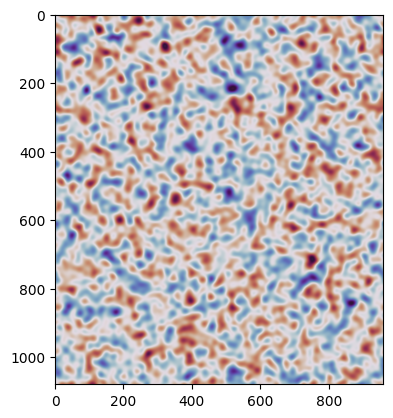

In [18]:
amplitude = 2**25
sigma = 0.5 / 2 / np.pi

phase_mask = fourier_phase_screen(slm.height, slm.width // 2, amplitude=amplitude, sigma=sigma)
phase_transformation = np.exp(1j * phase_mask)
rotated_phase_transformation = affine_transform(phase_transformation, inv(u_direct))

plt.imshow(np.angle(phase_transformation), cmap="twilight")

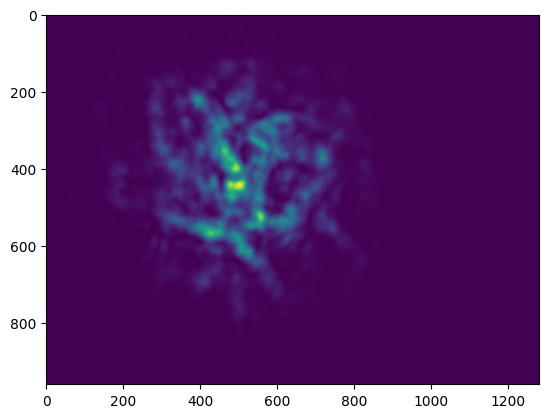

In [19]:
with h5py.File("../turbulence_compensation/data/output.h5") as file:
    data = file["fields"][:]
    u0 = np.sqrt(data[:, 0]) * np.exp(1j * data[:, 1])

mode = u0[0]
slm_mode = resize_and_center(mode, target_shape, 1)

# mode = slmcontrol.lg(xs, ys, p=1, l=0, w=30)
# slm_mode = resize_and_center(mode, target_shape, 1)

two_pi_modulation = 192

holo_mode = slmcontrol.generate_hologram(slm_mode, two_pi_modulation, -3, 19)
holo_fourier = slmcontrol.generate_hologram(np.ones_like(slm_mode), two_pi_modulation, -3, 19)
holo_phase_fourier = slmcontrol.generate_hologram(np.flip(phase_transformation), two_pi_modulation, -3, 19)

holo1 = np.concatenate([holo_fourier, holo_mode], axis=1)
holo2 = np.concatenate([holo_phase_fourier, holo_mode], axis=1)

slm.updateArray(holo2)

camera_direct.set_exposure(100)
camera_reciprocal.set_exposure(50)


slm.updateArray(holo1)
image_direct = np.flip(camera_direct.capture(), axis=0)
image_fourier = np.flip(camera_reciprocal.capture(), axis=0)
slm.updateArray(holo2)
image_phase_fourier = np.flip(camera_reciprocal.capture(), axis=0)

bg_direct = 2
bg_reciprocal = 5

image_direct = remove_background(image_direct, bg_direct)
image_fourier = remove_background(image_fourier, bg_reciprocal)
image_phase_fourier = remove_background(image_phase_fourier, bg_reciprocal)


corrected_image_direct = affine_transform(image_direct, A_direct, t_direct, mode.shape)
corrected_image_fourier = affine_transform(image_fourier, A_reciprocal, t_reciprocal, mode.shape)
corrected_image_phase_fourier = affine_transform(image_phase_fourier, A_reciprocal, t_reciprocal, mode.shape)

# plt.imshow(np.abs(slm_mode)**2)
plt.imshow(image_direct)

In [20]:
initial_phases = jax.random.uniform(jax.random.key(0), (10, *mode.shape))

direct_amplitude = np.sqrt(corrected_image_direct).astype(np.float32)
fourier_amplitude = np.fft.fftshift(np.sqrt(corrected_image_fourier).astype(np.float32))
phase_fourier_amplitude = np.fft.fftshift(np.sqrt(corrected_image_phase_fourier).astype(np.float32))

direct_amplitude /= norm(direct_amplitude)
fourier_amplitude *= np.sqrt(np.prod(mode.shape)) / norm(fourier_amplitude)
phase_fourier_amplitude *= np.sqrt(np.prod(mode.shape)) / norm(phase_fourier_amplitude)

cropped_phase_transformation = resize_and_center(phase_transformation, mode.shape, 1)

u_fourier = jnp.fft.fft2(mode)
u_phase_fourier = jnp.fft.fft2(cropped_phase_transformation * mode)

predicted_phase = augmented_gs(
    direct_amplitude, fourier_amplitude, phase_fourier_amplitude, cropped_phase_transformation, initial_phases, 200
)

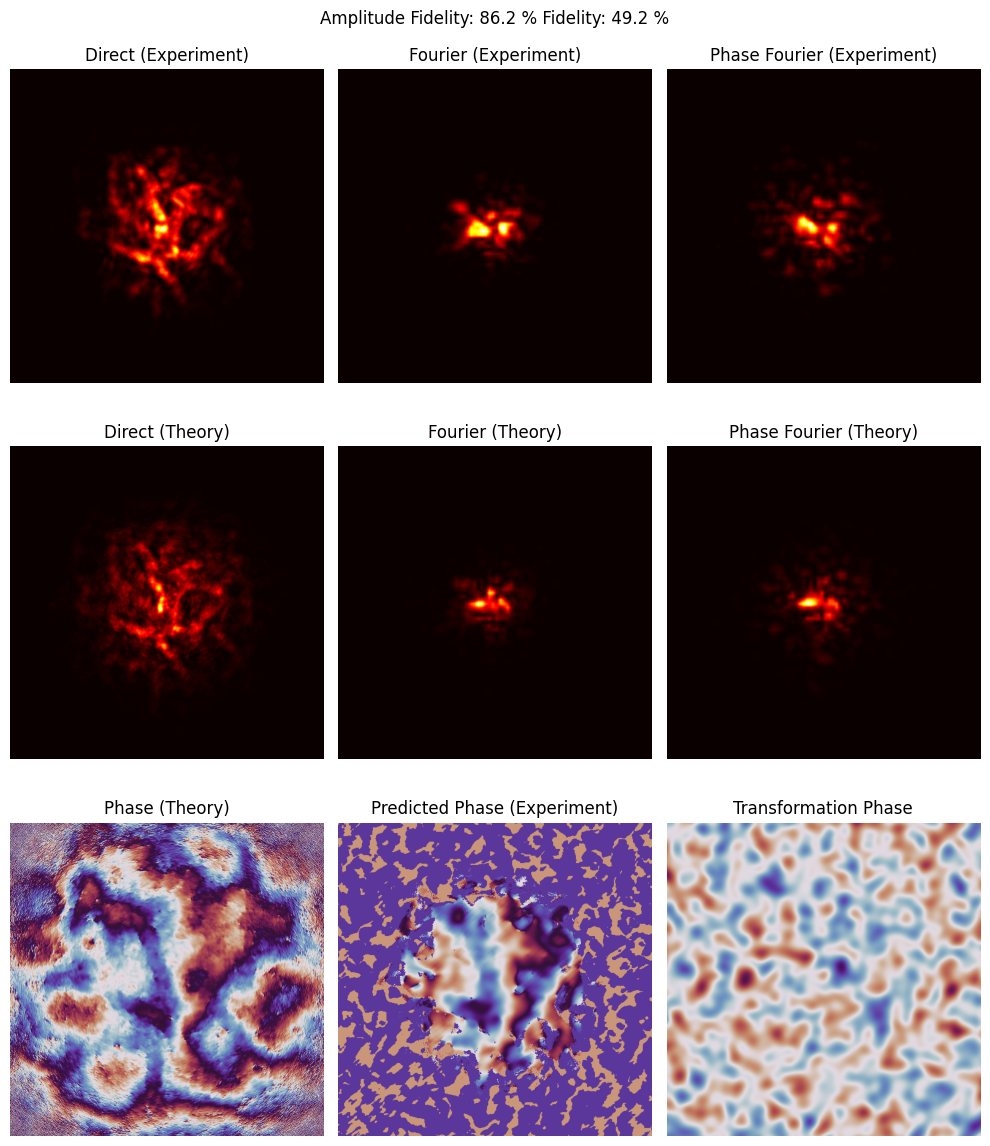

In [21]:
amplitude_fidelity = fidelity(np.complex64(jnp.abs(mode)), np.complex64(direct_amplitude))
fid = fidelity(mode, direct_amplitude * jnp.exp(1j * predicted_phase))

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 12))
fig.suptitle(f"Amplitude Fidelity: {100 * amplitude_fidelity:.1f} % Fidelity: {100 * fid:.1f} %")

axs[0, 0].imshow(resize_and_center(jnp.abs(direct_amplitude) ** 2, xs.shape, 1), cmap="hot")
axs[0, 0].set_title("Direct (Experiment)")

axs[0, 1].imshow(resize_and_center(jnp.abs(np.fft.ifftshift(fourier_amplitude)) ** 2, xs.shape, 6), cmap="hot")
axs[0, 1].set_title("Fourier (Experiment)")

axs[0, 2].imshow(resize_and_center(jnp.abs(np.fft.ifftshift(phase_fourier_amplitude)) ** 2, xs.shape, 6), cmap="hot")
axs[0, 2].set_title("Phase Fourier (Experiment)")

axs[1, 0].imshow(resize_and_center(jnp.abs(mode) ** 2, xs.shape, 1), cmap="hot")
axs[1, 0].set_title("Direct (Theory)")

axs[1, 1].imshow(resize_and_center(jnp.abs(np.fft.ifftshift(u_fourier)) ** 2, xs.shape, 6), cmap="hot")
axs[1, 1].set_title("Fourier (Theory)")

axs[1, 2].imshow(resize_and_center(jnp.abs(np.fft.ifftshift(u_phase_fourier)) ** 2, xs.shape, 6), cmap="hot")
axs[1, 2].set_title("Phase Fourier (Theory)")

axs[2, 0].imshow(
    resize_and_center(set_phase_reference(jnp.angle(mode), posX=0.40, posY=0.40), xs.shape, 1),
    cmap="twilight",
    vmin=-jnp.pi,
    vmax=jnp.pi,
)
axs[2, 0].set_title("Phase (Theory)")

axs[2, 1].imshow(
    resize_and_center(set_phase_reference(predicted_phase, posX=0.40, posY=0.40), xs.shape, 1),
    cmap="twilight",
    vmin=-jnp.pi,
    vmax=jnp.pi,
)
axs[2, 1].set_title("Predicted Phase (Experiment)")

axs[2, 2].imshow(resize_and_center(np.angle(cropped_phase_transformation), xs.shape, 1), cmap="twilight", vmin=-jnp.pi, vmax=jnp.pi)
axs[2, 2].set_title("Transformation Phase")

for m in range(axs.shape[0]):
    for n in range(axs.shape[1]):
        axs[m, n].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
camera_reciprocal.close()